# CITS5508: Assignment 1
**Name:** James Wigfield 

**Student ID:** 23334375 

Semester 1, 2026

## Part 1: Softmax Regression

### 1.1 Data Loading and Exploration
in this section...


In [10]:
from sklearn.datasets import fetch_openml
import numpy as np

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [11]:
# Basic dataset info
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for digit, count in zip(unique, counts):
    print(f"  Digit {int(digit)}: {count} samples ({100*count/len(y):.2f}%)")

# Data type and value ranges
print(f"\nData type: {X.dtype}")
print(f"Value range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Mean pixel value: {X.mean():.2f}")
print(f"Std pixel value: {X.std():.2f}")

# Missing values
print(f"Missing values: {np.isnan(X).sum()}")

Dataset shape: X=(70000, 784), y=(70000,)
Number of samples: 70000
Number of features: 784
Number of classes: 10
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Class distribution:
  Digit 0: 6903 samples (9.86%)
  Digit 1: 7877 samples (11.25%)
  Digit 2: 6990 samples (9.99%)
  Digit 3: 7141 samples (10.20%)
  Digit 4: 6824 samples (9.75%)
  Digit 5: 6313 samples (9.02%)
  Digit 6: 6876 samples (9.82%)
  Digit 7: 7293 samples (10.42%)
  Digit 8: 6825 samples (9.75%)
  Digit 9: 6958 samples (9.94%)

Data type: int64
Value range: [0.0, 255.0]
Mean pixel value: 33.39
Std pixel value: 78.65
Missing values: 0


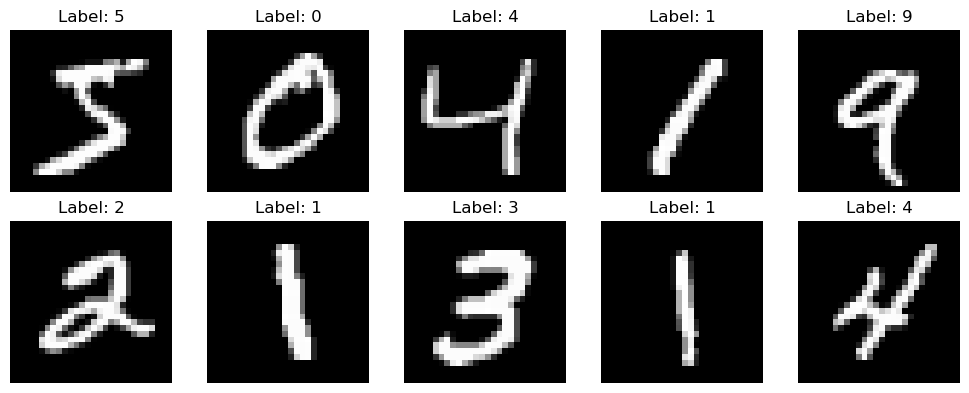

In [12]:
import matplotlib.pyplot as plt

# Display the first 10 images and their labels
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Dataset Description
This is a famous dataset, as seen from the previously printed statistics from this dataset...

### 1.2 Data Splitting
70% training etc...

In [13]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the 30% evenly (15% val and test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set: X_val={X_val.shape}, y_val={y_val.shape}")

Training set: X_train=(49000, 784), y_train=(49000,)
Validation set: X_val=(10500, 784), y_val=(10500,)


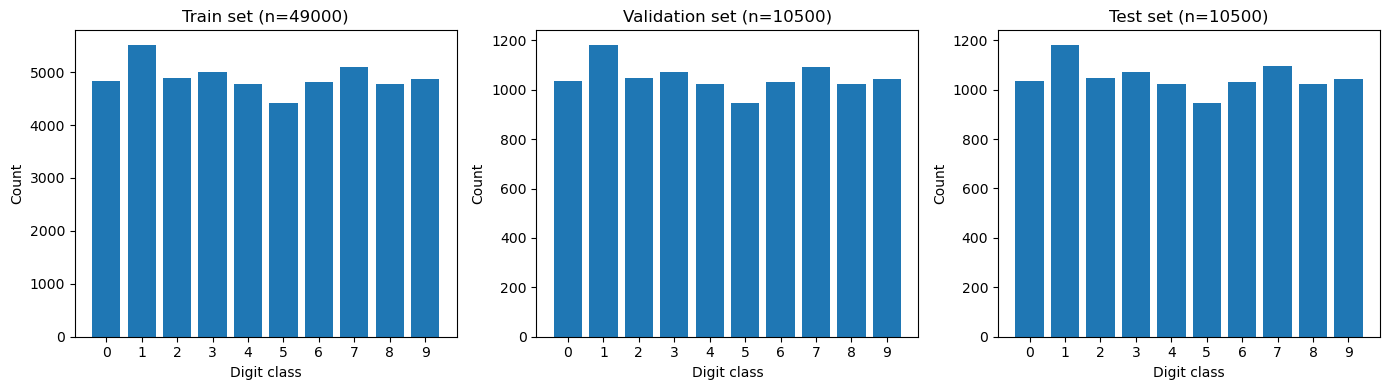

In [14]:
# Display Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]

for ax, (name, labels) in zip(axes, splits):
    classes, counts = np.unique(labels, return_counts=True)
    ax.bar(classes, counts)
    ax.set_title(f'{name} set (n={len(labels)})')
    ax.set_xlabel('Digit class')
    ax.set_ylabel('Count')
    ax.set_xticks(classes)

plt.tight_layout()
plt.show()

#### Stratification Justification
answer to task 3b

### 1.3 Softmax Regression Implementation

Here we implement softmax regression from scratch using only NumPy. The model uses **mini-batch gradient descent** to minimise the cross-entropy loss, and applies **early stopping** based on the validation loss to prevent overfitting.

Before training, pixel values are normalised from [0, 255] to [0, 1]. This is important: without scaling, the large raw pixel values produce extremely large dot products, causing numerical overflow in the softmax exponentials and making gradient descent unstable.

The core mathematics follows the assignment formulas directly:
- The softmax function converts raw class scores into probabilities
- The cross-entropy loss measures how far predicted probabilities are from the true one-hot labels
- The gradient update nudges the weight matrix in the direction that reduces loss

In [15]:
# Normalise pixel values from [0, 255] to [0, 1]
X_train_norm = X_train / 255.0
X_val_norm   = X_val   / 255.0
X_test_norm  = X_test  / 255.0

class SoftmaxRegression:
    """Softmax regression via mini-batch gradient descent with early stopping."""

    def __init__(self, lr=0.1, max_epochs=200, batch_size=256, patience=15, random_state=42):
        self.lr         = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience   = patience
        self.rng        = np.random.default_rng(random_state)

    def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

    def _softmax(self, Z):
        # Subtract row-wise max for numerical stability before exp
        Z_shift = Z - Z.max(axis=1, keepdims=True)
        exp_Z   = np.exp(Z_shift)
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def _one_hot(self, y):
        indices = np.array([self.class_to_idx_[label] for label in y])
        Y = np.zeros((len(y), len(self.classes_)))
        Y[np.arange(len(y)), indices] = 1
        return Y

    def _cross_entropy(self, X_b, Y_oh):
        P = self._softmax(X_b @ self.W_)
        return -np.mean(np.sum(Y_oh * np.log(P + 1e-15), axis=1))

    def fit(self, X, y, X_val, y_val):
        self.classes_      = np.unique(y)
        self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}

        X_b     = self._add_bias(X)
        X_val_b = self._add_bias(X_val)
        Y_oh    = self._one_hot(y)
        Y_val   = self._one_hot(y_val)

        m, n = X_b.shape
        K    = len(self.classes_)

        self.W_ = np.zeros((n, K))
        self.train_losses_ = []
        self.val_losses_   = []

        best_val_loss = np.inf
        best_W        = self.W_.copy()
        no_improve    = 0

        for epoch in range(self.max_epochs):
            perm   = self.rng.permutation(m)
            X_shuf = X_b[perm]
            Y_shuf = Y_oh[perm]

            for start in range(0, m, self.batch_size):
                Xb   = X_shuf[start : start + self.batch_size]
                Yb   = Y_shuf[start : start + self.batch_size]
                P    = self._softmax(Xb @ self.W_)
                grad = Xb.T @ (P - Yb) / len(Xb)
                self.W_ -= self.lr * grad

            train_loss = self._cross_entropy(X_b, Y_oh)
            val_loss   = self._cross_entropy(X_val_b, Y_val)
            self.train_losses_.append(train_loss)
            self.val_losses_.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_W        = self.W_.copy()
                no_improve    = 0
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    print(f"Early stopping at epoch {epoch + 1} "
                          f"(best val loss: {best_val_loss:.4f})")
                    break

        self.W_            = best_W
        self.n_epochs_run_ = len(self.train_losses_)
        return self

    def predict_proba(self, X):
        return self._softmax(self._add_bias(X) @ self.W_)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [16]:
model = SoftmaxRegression(lr=0.1, max_epochs=200, batch_size=256, patience=15, random_state=42)
model.fit(X_train_norm, y_train, X_val_norm, y_val)

train_acc = np.mean(model.predict(X_train_norm) == y_train)
val_acc   = np.mean(model.predict(X_val_norm)   == y_val)
print(f"Epochs run:          {model.n_epochs_run_}")
print(f"Train accuracy:      {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Early stopping at epoch 146 (best val loss: 0.2933)
Epochs run:          146
Train accuracy:      0.9330
Validation accuracy: 0.9199


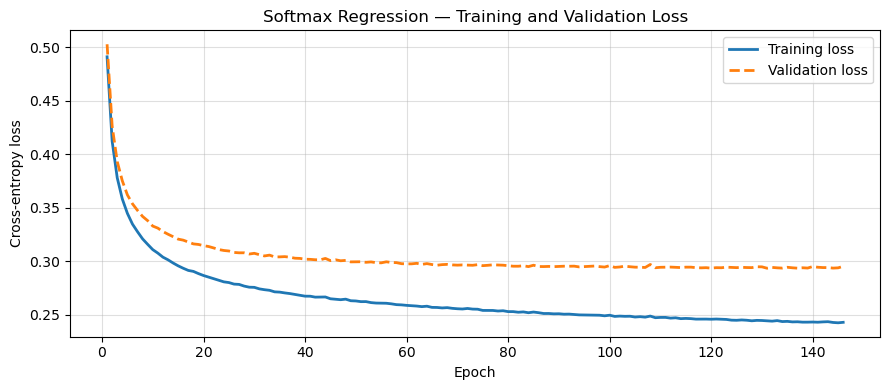

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(model.train_losses_) + 1)

ax.plot(epochs, model.train_losses_, label='Training loss',   linewidth=2)
ax.plot(epochs, model.val_losses_,   label='Validation loss', linewidth=2, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Softmax Regression — Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### Training Observations:
Answer Task 4b here: Comment on the loss curves. Did the model converge? When did early stopping kick in? Is this what you expected?

### 1.4 Scikit-Learn Logistic Regression Comparison

To validate our from-scratch implementation we compare it against scikit-learn's `LogisticRegression`, which uses the **L-BFGS** optimiser — a quasi-Newton second-order method that converges far more efficiently than our gradient descent. We set `penalty=None` to disable regularisation as required by the assignment.

The comparison covers:
- Accuracy on training and test sets for both models
- Confusion matrices showing per-class error patterns on the test set
- Per-class precision, recall, and F1-score via `classification_report`

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# penalty=None disables regularisation as required by the assignment brief
sklearn_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
sklearn_model.fit(X_train_norm, y_train)

print(f"{'Model':<30}  {'Train acc':>10}  {'Test acc':>10}")
print("-" * 56)
for name, clf in [('Custom Softmax Regression', model), ('sklearn LogisticRegression', sklearn_model)]:
    tr = accuracy_score(y_train, clf.predict(X_train_norm))
    te = accuracy_score(y_test,  clf.predict(X_test_norm))
    print(f"{name:<30}  {tr:>10.4f}  {te:>10.4f}")

Model                            Train acc    Test acc
--------------------------------------------------------
Custom Softmax Regression           0.9330      0.9208
sklearn LogisticRegression          0.9453      0.9130


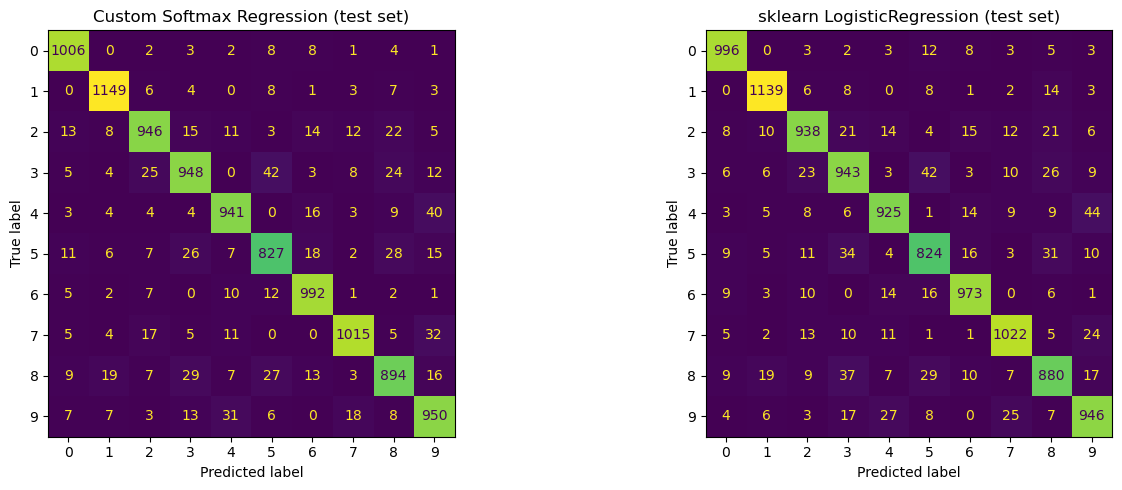

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, model.predict(X_test_norm),
    ax=axes[0], colorbar=False
)
axes[0].set_title('Custom Softmax Regression (test set)')

ConfusionMatrixDisplay.from_predictions(
    y_test, sklearn_model.predict(X_test_norm),
    ax=axes[1], colorbar=False
)
axes[1].set_title('sklearn LogisticRegression (test set)')

plt.tight_layout()
plt.show()

In [20]:
print("=== Custom Softmax Regression — Test Set ===")
print(classification_report(y_test, model.predict(X_test_norm), digits=4))

print("=== sklearn LogisticRegression — Test Set ===")
print(classification_report(y_test, sklearn_model.predict(X_test_norm), digits=4))

=== Custom Softmax Regression — Test Set ===
              precision    recall  f1-score   support

           0     0.9455    0.9720    0.9586      1035
           1     0.9551    0.9729    0.9639      1181
           2     0.9238    0.9018    0.9127      1049
           3     0.9054    0.8852    0.8952      1071
           4     0.9225    0.9189    0.9207      1024
           5     0.8864    0.8733    0.8798       947
           6     0.9315    0.9612    0.9461      1032
           7     0.9522    0.9278    0.9398      1094
           8     0.8913    0.8730    0.8821      1024
           9     0.8837    0.9108    0.8971      1043

    accuracy                         0.9208     10500
   macro avg     0.9197    0.9197    0.9196     10500
weighted avg     0.9207    0.9208    0.9206     10500

=== sklearn LogisticRegression — Test Set ===
              precision    recall  f1-score   support

           0     0.9495    0.9623    0.9559      1035
           1     0.9531    0.9644    0.95

#### Model Comparison & Evaluation

*(Write your commentary here in your own words. Use the printed metrics and confusion matrices above as evidence. Some questions to address:)*

- *How close are the two models in accuracy? Is the gap larger on train or test?*
- *Which digit pairs cause the most confusion in both models — are they the same pairs?*
- *Did the sklearn model improve noticeably on the hard classes (e.g. 4 vs 9, 3 vs 8)?*
- *Is the result what you expected given that both models are fundamentally linear classifiers?*
- *What does the train vs test accuracy gap tell you about overfitting for each model?*

## Part 2: Support Vector Machine Regression

### 2.1 Dataset Generation

We generate synthetic polynomial datasets of the form:

$$y = \sum_{k=0}^{n} a_k x^k + \varepsilon$$

where $x \in [-3, 3]$, coefficients $a_k \sim \mathcal{U}(0, 1)$, and noise $\varepsilon \sim \mathcal{N}(0, 1)$.

The function `generate_polynomial_dataset(degree, n_samples)` encapsulates this generation process. We then verify it visually using demo plots for degree = 1, 2, and 3, before generating the three full datasets (linear, quadratic, cubic) with train/test splits for use in the SVR experiments.

In [ ]:
def generate_polynomial_dataset(degree, n_samples, random_state=42):
    rng = np.random.default_rng(random_state)
    x   = rng.uniform(-3, 3, n_samples)
    a   = rng.uniform(0, 1, degree + 1)           # coefficients a_0, ..., a_degree
    y   = sum(a[k] * x**k for k in range(degree + 1)) + rng.standard_normal(n_samples)
    return x.reshape(-1, 1), y

# Verification plots for degree = 1, 2, 3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [('Linear (degree=1)', 1, 10), ('Quadratic (degree=2)', 2, 20), ('Cubic (degree=3)', 3, 30)]

for ax, (title, degree, seed) in zip(axes, configs):
    X_demo, y_demo = generate_polynomial_dataset(degree, n_samples=300, random_state=seed)
    ax.scatter(X_demo, y_demo, s=8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.suptitle('generate_polynomial_dataset — verification plots')
plt.tight_layout()
plt.show()

In [ ]:
# Generate the three datasets — different seeds so each has independent x values and coefficients
X_lin,  y_lin  = generate_polynomial_dataset(degree=1, n_samples=1000, random_state=10)
X_quad, y_quad = generate_polynomial_dataset(degree=2, n_samples=1000, random_state=20)
X_cub,  y_cub  = generate_polynomial_dataset(degree=3, n_samples=1000, random_state=30)

# Train/test splits (80/20)
X_lin_train,  X_lin_test,  y_lin_train,  y_lin_test  = train_test_split(X_lin,  y_lin,  test_size=0.2, random_state=42)
X_quad_train, X_quad_test, y_quad_train, y_quad_test = train_test_split(X_quad, y_quad, test_size=0.2, random_state=42)
X_cub_train,  X_cub_test,  y_cub_train,  y_cub_test  = train_test_split(X_cub,  y_cub,  test_size=0.2, random_state=42)

print(f"Linear:    train={X_lin_train.shape},  test={X_lin_test.shape}")
print(f"Quadratic: train={X_quad_train.shape},  test={X_quad_test.shape}")
print(f"Cubic:     train={X_cub_train.shape},  test={X_cub_test.shape}")

### 2.2 SVR with Different Kernels 
Explain that you will now fit SVR models with linear, polynomial, and RBF kernels to the three synthetic datasets

In [23]:
# set up a loop or grid to train skleanr.svm.SVR models.

#### Kernel Performance Analysis
(Answer Task 3b here: Discuss the plots. Did the linear kernel underfit the cubic data? How did the RBF kernel handle the different degrees? Are the results matching your expectations of how these kernels transform the feature space?)

### 2.3 Hyperparameter Tuning via Grid Search
(Introduce the grid search process on the cubic dataset)

In [24]:
# import GridSearchCV

#### Grid Search Results: 
(Answer Task 4a and 4b here. List the exact hyperparameters you chose and why. State the total number of models fitted during the CV process. Present the best parameters found by the grid search)

### 2.4 Optimal Model Evaluation
(evaluate the best model on unseen data)

In [25]:
# extract the best estimateor from grid search 

### Final Conclusion 